# 05 Korelasi dan Regresi Sederhana

## Hasil pembelajaran

Setelah notebook ini, Anda dapat:

- Menghitung korelasi antara dua variabel;
- Membedakan korelasi dari kausalitas;
- Menjalankan regresi linear sederhana;
- Menginterpretasikan koefisien regresi dengan hati-hati;
- Memahami keterbatasan regresi pada data observasional.

### Penanda Sel Kode
- `# RUN-NOW`: dapat langsung dijalankan.
- `# LEARNER-TASK`: ubah bagian bertanda [UBAH]/[ANDA TULIS], lalu jalankan.

## ⚠️ Korelasi ≠ Kausalitas

**PENTING:** Dua variabel berkorelasi (asosiasi statistik) TIDAK berarti salah satunya menyebabkan yang lain.

**Contoh:**
- Es krim penjualan ↑ → Kasus tenggelam ↑ (korelasi positif)
- Tapi es krim TIDAK menyebabkan tenggelam!
- Confounder: Musim panas → kedua variabel naik

**Untuk membuktikan kausalitas, perlu:**
1. Randomized experiment (random assignment ke treatment & control)
2. Atau causal inference design yang canggih
3. Data observasional TIDAK cukup untuk membuktikan kausalitas

**Data kami adalah observasional** → Hanya dapat menunjukkan asosiasi, bukan penyebab.

In [1]:
# RUN-NOW: Jalankan sel ini apa adanya.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from pathlib import Path

# Muat data bersih — dengan fallback untuk berbagai working directory
candidate_paths = [
    Path("data/processed/student_performance_cleaned.csv"),
    Path("../data/processed/student_performance_cleaned.csv"),
    Path("/workspaces/metpen-ai-lab/data/processed/student_performance_cleaned.csv"),
]

cleaned_file = next((p for p in candidate_paths if p.exists()), None)
if cleaned_file is None:
    raise FileNotFoundError(
        "❌ File data bersih tidak ditemukan.\n"
        "Anda perlu menjalankan notebook 02 (02_data_quality_cleaning.ipynb) terlebih dahulu\n"
        "untuk membuat file: data/processed/student_performance_cleaned.csv"
    )

df = pd.read_csv(cleaned_file)

print(f"✓ Data dimuat dari: {cleaned_file.resolve()}")
print(f"✓ Data dimuat: {df.shape[0]} baris")

✓ Data dimuat dari: C:\Users\jardm\Documents\metpen\Metpen\metpen-ai-lab\notebooks\data\processed\student_performance_cleaned.csv
✓ Data dimuat: 2000 baris


## Matriks Korelasi

In [2]:
# RUN-NOW: Jalankan sel ini apa adanya.
# Pilih variabel numerik untuk korelasi
numeric_cols = [
    'attendance_rate',
    'assignment_score',
    'quiz_average',
    'midterm_score',
    'final_exam_score',
    'study_hours_per_week',
    'submission_delay_days',
    'final_grade'
]

# Hitung correlation matrix
corr_matrix = df[numeric_cols].corr()

print("MATRIKS KORELASI PEARSON")
print("(Nilai -1 hingga +1, di mana +1 = sempurna positif, -1 = sempurna negatif)")
print(corr_matrix.round(3))

MATRIKS KORELASI PEARSON
(Nilai -1 hingga +1, di mana +1 = sempurna positif, -1 = sempurna negatif)
                       attendance_rate  assignment_score  quiz_average  \
attendance_rate                  1.000             0.359         0.422   
assignment_score                 0.359             1.000         0.398   
quiz_average                     0.422             0.398         1.000   
midterm_score                    0.382             0.287         0.382   
final_exam_score                 0.386             0.285         0.428   
study_hours_per_week            -0.014             0.515         0.243   
submission_delay_days            0.006            -0.164         0.001   
final_grade                      0.612             0.663         0.671   

                       midterm_score  final_exam_score  study_hours_per_week  \
attendance_rate                0.382             0.386                -0.014   
assignment_score               0.287             0.285                 0.

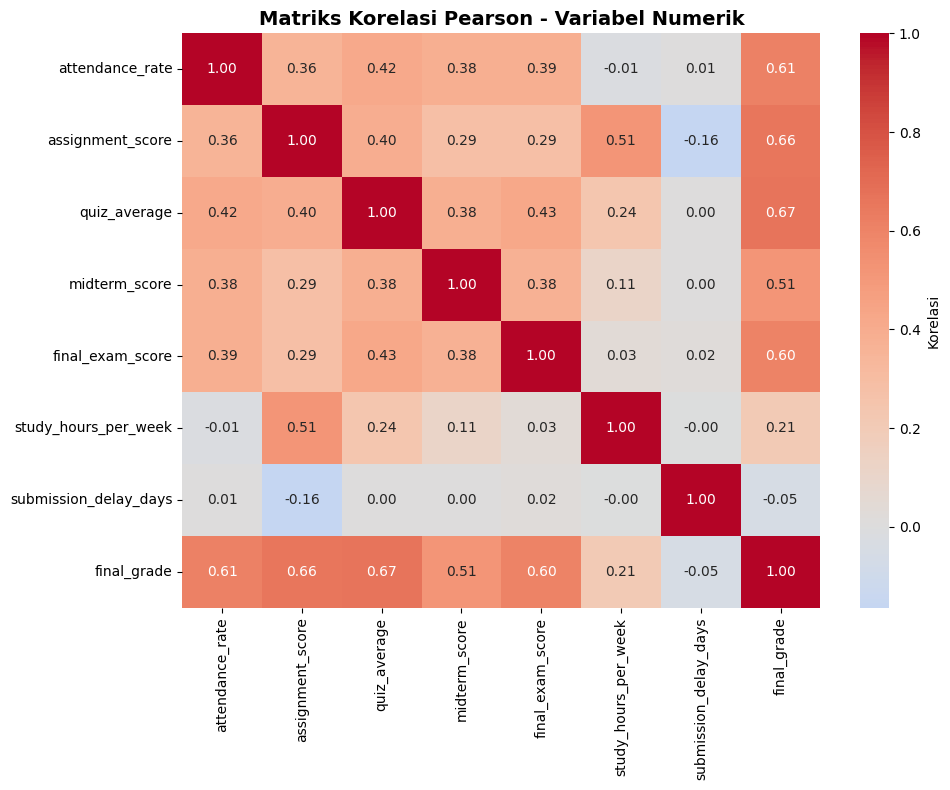

Interpretasi warna:
  Merah = Korelasi positif kuat
  Putih = Tidak ada korelasi
  Biru = Korelasi negatif kuat


In [3]:
# RUN-NOW: Jalankan sel ini apa adanya.
## Visualisasi Matriks Korelasi

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Korelasi'})
plt.title('Matriks Korelasi Pearson - Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretasi warna:")
print("  Merah = Korelasi positif kuat")
print("  Putih = Tidak ada korelasi")
print("  Biru = Korelasi negatif kuat")

## Regresi Linear Sederhana: attendance → final_grade

In [4]:
# RUN-NOW: Jalankan sel ini apa adanya.
# Data untuk regresi
X = df[['attendance_rate']].values  # Prediktor (independent)
y = df['final_grade'].values         # Outcome (dependent)

# Fit model
model = LinearRegression()
model.fit(X, y)

# Ekstrak parameter
intercept = model.intercept_
slope = model.coef_[0]
r_squared = model.score(X, y)

print("REGRESI LINEAR: final_grade ~ attendance_rate")
print("="*50)
print(f"Rumus: final_grade = {intercept:.2f} + {slope:.2f} × attendance_rate")
print(f"\nInterpretasi koefisien:")
print(f"  - Intercept ({intercept:.2f}): Nilai prediksi jika attendance = 0%")
print(f"  - Slope ({slope:.2f}): Setiap +1% kehadiran → final_grade naik {slope:.2f}")
print(f"\nR² = {r_squared:.3f}")
print(f"  → {r_squared*100:.1f}% variasi final_grade dijelaskan oleh attendance_rate")
print(f"  → {(1-r_squared)*100:.1f}% dijelaskan oleh variabel lain (error)")

REGRESI LINEAR: final_grade ~ attendance_rate
Rumus: final_grade = 50.72 + 0.44 × attendance_rate

Interpretasi koefisien:
  - Intercept (50.72): Nilai prediksi jika attendance = 0%
  - Slope (0.44): Setiap +1% kehadiran → final_grade naik 0.44

R² = 0.375
  → 37.5% variasi final_grade dijelaskan oleh attendance_rate
  → 62.5% dijelaskan oleh variabel lain (error)


## Visualisasi: Scatter + Garis Regresi

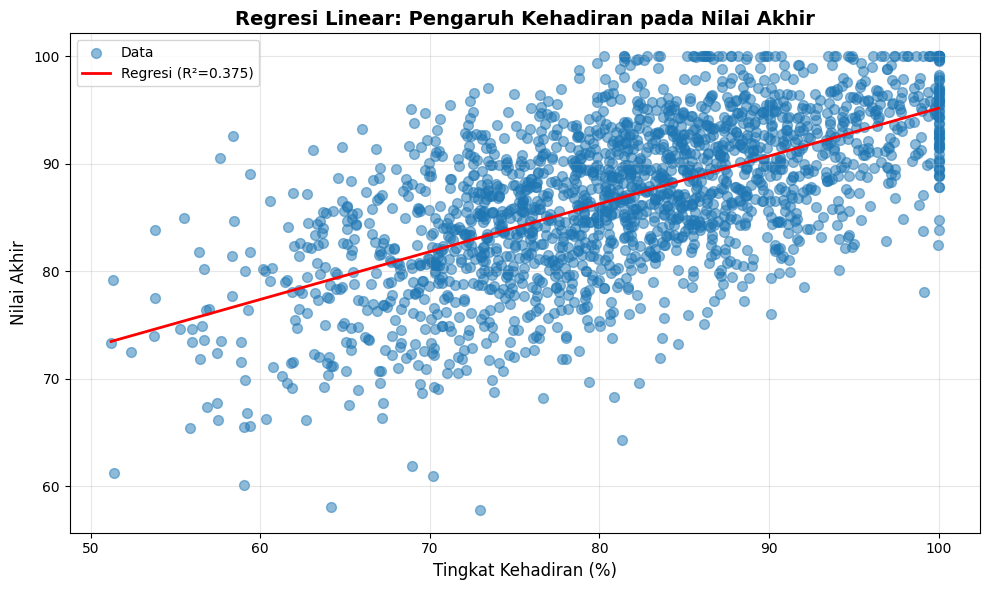

In [5]:
# RUN-NOW: Jalankan sel ini apa adanya.
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(df['attendance_rate'], df['final_grade'], alpha=0.5, s=50, label='Data')

# Garis regresi
X_line = np.array([[df['attendance_rate'].min()], [df['attendance_rate'].max()]])
y_line = model.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2, label=f'Regresi (R²={r_squared:.3f})')

plt.xlabel('Tingkat Kehadiran (%)', fontsize=12)
plt.ylabel('Nilai Akhir', fontsize=12)
plt.title('Regresi Linear: Pengaruh Kehadiran pada Nilai Akhir', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Regresi Berganda (Multiple Regression)

In [6]:
# RUN-NOW: Jalankan sel ini apa adanya.
# Pilih beberapa prediktor
predictors = ['attendance_rate', 'previous_gpa', 'study_hours_per_week', 'submission_delay_days']
X_multi = df[predictors].values
y_multi = df['final_grade'].values

# Fit model berganda
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

r_squared_multi = model_multi.score(X_multi, y_multi)

print("REGRESI BERGANDA")
print("="*60)
print(f"Rumus: final_grade ~ attendance + previous_gpa + study_hours + submission_delay")
print(f"\nKoefisien regresi:")
for pred, coef in zip(predictors, model_multi.coef_):
    print(f"  {pred:25s}: {coef:8.4f}")
print(f"  {'Intercept':25s}: {model_multi.intercept_:8.4f}")

print(f"\nR² = {r_squared_multi:.3f}")
print(f"  → {r_squared_multi*100:.1f}% variasi dijelaskan oleh model ini")
print(f"\nPerbandingan dengan regresi sederhana:")
print(f"  R² sederhana (attendance only): {r_squared:.3f}")
print(f"  R² berganda (4 prediktor):      {r_squared_multi:.3f}")
print(f"  Peningkatan: {(r_squared_multi - r_squared)*100:.1f}%")

REGRESI BERGANDA
Rumus: final_grade ~ attendance + previous_gpa + study_hours + submission_delay

Koefisien regresi:
  attendance_rate          :   0.3528
  previous_gpa             :   9.2567
  study_hours_per_week     :   0.3551
  submission_delay_days    :  -0.2680
  Intercept                :  26.7930

R² = 0.736
  → 73.6% variasi dijelaskan oleh model ini

Perbandingan dengan regresi sederhana:
  R² sederhana (attendance only): 0.375
  R² berganda (4 prediktor):      0.736
  Peningkatan: 36.1%


## Interpretasi dengan hati-hati

### Apa yang dapat disimpulkan:
✓ Ada asosiasi positif antara kehadiran dan nilai akhir
✓ Asosiasi ini agak kuat (r ≈ ?)
✓ Untuk setiap +1% kehadiran, nilai prediksi meningkat ~? poin
✓ Kehadiran, GPA sebelumnya, dan study hours bersama menjelaskan ~? % variasi nilai

### Apa TIDAK dapat disimpulkan:
✗ Kehadiran MENYEBABKAN nilai lebih tinggi (mungkin ada confounder)
✗ Jika mahasiswa kehadiran ↑ 10%, pasti nilai naik [slope] × 10
✗ Hubungannya tetap sama untuk semua mahasiswa (linearitas diasumsikan)
✗ Model ini prediksi sempurna (ada banyak error)

### Kemungkinan confounder:
? Motivasi mahasiswa → kehadiran tinggi AND belajar keras → nilai tinggi
? Status kesehatan → kehadiran stabil AND performa stabil
? Disiplin pribadi → kehadiran baik AND nilai baik

## Diagnostik model: Residual

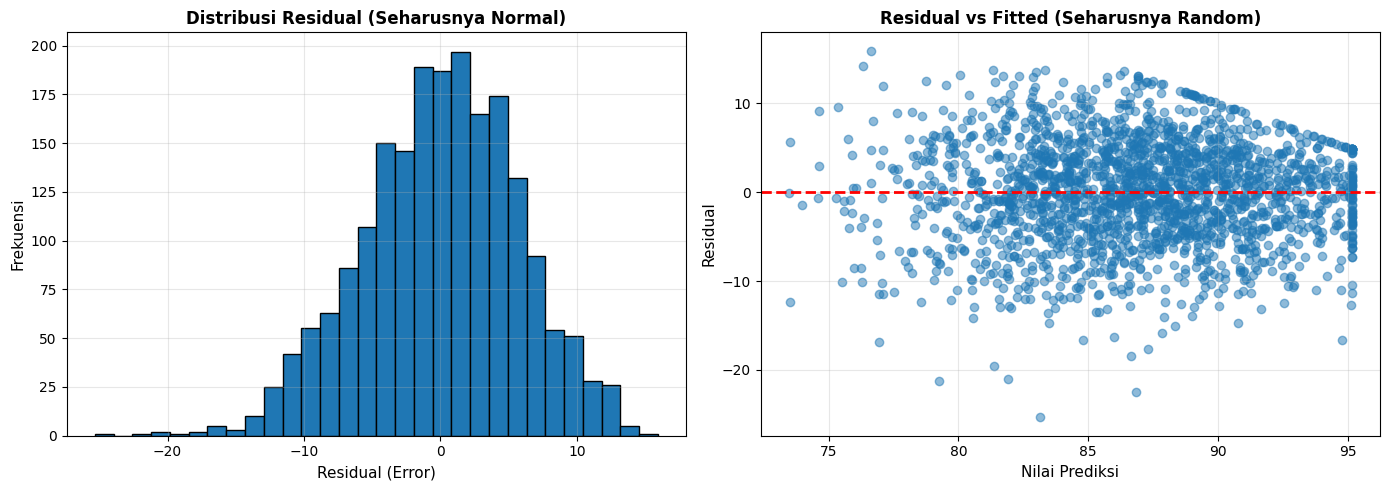

Statistik Residual:
  Mean: 0.0000 (seharusnya ≈ 0)
  Std:  5.75


In [7]:
# RUN-NOW: Jalankan sel ini apa adanya.
# Hitung residual (error)
y_pred = model.predict(X)
residuals = y - y_pred

# Plot residual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram residual
axes[0].hist(residuals, bins=30, edgecolor='black')
axes[0].set_xlabel('Residual (Error)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Residual (Seharusnya Normal)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Scatter: Predicted vs Residual
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Nilai Prediksi', fontsize=11)
axes[1].set_ylabel('Residual', fontsize=11)
axes[1].set_title('Residual vs Fitted (Seharusnya Random)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Statistik Residual:")
print(f"  Mean: {residuals.mean():.4f} (seharusnya ≈ 0)")
print(f"  Std:  {residuals.std():.2f}")

## Keterbatasan regresi pada data observasional

In [8]:
# RUN-NOW: Jalankan sel ini apa adanya.
print("""
KETERBATASAN ANALISIS REGRESI INI
==================================

1. DATA OBSERVASIONAL (bukan eksperimental)
   - Kami tidak mengontrol siapa yang kehadiran tinggi
   - Tidak bisa assign "kehadiran rendah" ke mahasiswa
   - Perbedaan kelompok mungkin karena faktor lain (confounder)

2. HUBUNGAN LINIER DIASUMSIKAN
   - Model mengasumsikan hubungan linear
   - Mungkin hubungan sebenarnya non-linear
   - Periksa plot residual untuk deteksi violation

3. R² RENDAH
   - Jika R² rendah, banyak variabilitas tidak dijelaskan
   - Ini normal untuk data sosial & perilaku
   - Tetap cari variabel penting yang hilang

4. SAMPLE TERTENTU SAJA
   - Data ini adalah synthetic & terbatas
   - Hasil mungkin tidak generalize ke populasi lain

KESIMPULANNYA:
✓ Regresi berguna untuk eksplorasi & prediksi
✗ Regresi TIDAK cocok untuk menyimpulkan kausalitas
""")


KETERBATASAN ANALISIS REGRESI INI

1. DATA OBSERVASIONAL (bukan eksperimental)
   - Kami tidak mengontrol siapa yang kehadiran tinggi
   - Tidak bisa assign "kehadiran rendah" ke mahasiswa
   - Perbedaan kelompok mungkin karena faktor lain (confounder)

2. HUBUNGAN LINIER DIASUMSIKAN
   - Model mengasumsikan hubungan linear
   - Mungkin hubungan sebenarnya non-linear
   - Periksa plot residual untuk deteksi violation

3. R² RENDAH
   - Jika R² rendah, banyak variabilitas tidak dijelaskan
   - Ini normal untuk data sosial & perilaku
   - Tetap cari variabel penting yang hilang

4. SAMPLE TERTENTU SAJA
   - Data ini adalah synthetic & terbatas
   - Hasil mungkin tidak generalize ke populasi lain

KESIMPULANNYA:
✓ Regresi berguna untuk eksplorasi & prediksi
✗ Regresi TIDAK cocok untuk menyimpulkan kausalitas



## Tugas Anda

Jalankan regresi untuk satu hubungan yang menarik Anda:

1. Pilih outcome variable (y) dan 1-2 prediktor (x)
2. Jalankan regresi linear
3. Interpretasikan koefisien
4. Catat R² dan artinya
5. Tuliskan kemungkinan confounder

Kode awal:

In [9]:
# LEARNER-TASK: Edit sesuai instruksi, lalu jalankan.
# Ganti dengan variabel pilihan Anda
my_outcome = 'final_grade'
my_predictor = 'study_hours_per_week'

X_my = df[[my_predictor]].values
y_my = df[my_outcome].values

model_my = LinearRegression()
model_my.fit(X_my, y_my)

print(f"Regresi: {my_outcome} ~ {my_predictor}")
print(f"Koefisien: {model_my.coef_[0]:.4f}")
print(f"Intercept: {model_my.intercept_:.4f}")
print(f"R²: {model_my.score(X_my, y_my):.3f}")

print("\nInterpretasi dan confounder Anda di sini:")

Regresi: final_grade ~ study_hours_per_week
Koefisien: 0.3361
Intercept: 83.1350
R²: 0.043

Interpretasi dan confounder Anda di sini:


## Langkah berikutnya

✓ Anda sudah memahami korelasi, regresi, dan keterbatasannya

→ Notebook terakhir (`06_case_study_template.ipynb`): Gabungkan semua workflow dalam studi kasus terpadu.